In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
df=pd.read_csv('twitter_training.csv',header=None,names=['TweetId','Entity','Sentiment','Text'])

In [110]:
df.head()

,TweetId,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [111]:
df.drop(['TweetId','Entity'], axis=1,inplace=True)

In [112]:
df.head()

,Sentiment,Text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


In [113]:
df.shape

(74682, 2)

In [114]:
df.isnull().sum()

,0
Sentiment,0
Text,686


In [115]:
df.dropna(inplace=True)

In [116]:
df.isnull().sum()

,0
Sentiment,0
Text,0


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73996 entries, 0 to 74681
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  73996 non-null  object
 1   Text       73996 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB


In [118]:
df.duplicated().sum()

np.int64(4227)

In [119]:
df.drop_duplicates(inplace=True)

In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
df['Sentiment'].value_counts()

,count
Sentiment,
Negative,21237
Positive,19138
Neutral,17110
Irrelevant,12284


In [122]:
from sklearn.preprocessing import LabelEncoder

In [123]:
le=LabelEncoder()
df['Sentiment']=le.fit_transform(df['Sentiment'])

In [124]:
df.head()

,Sentiment,Text
0,3,im getting on borderlands and i will murder yo...
1,3,I am coming to the borders and I will kill you...
2,3,im getting on borderlands and i will kill you ...
3,3,im coming on borderlands and i will murder you...
4,3,im getting on borderlands 2 and i will murder ...


In [125]:
df['Text']=df['Text'].apply(lambda x:x.lower())

In [126]:
df.head()

,Sentiment,Text
0,3,im getting on borderlands and i will murder yo...
1,3,i am coming to the borders and i will kill you...
2,3,im getting on borderlands and i will kill you ...
3,3,im coming on borderlands and i will murder you...
4,3,im getting on borderlands 2 and i will murder ...


In [127]:
import string

def remove_punc(txt):
  return txt.translate(str.maketrans('','',string.punctuation))

In [128]:
df['Text']=df['Text'].apply(remove_punc)

In [129]:
def remove_num(txt):
  result=''.join([i for i in txt if not i.isdigit()])
  return result


In [130]:
df['Text']=df['Text'].apply(remove_num)

In [131]:
def remove_emoji(txt):
  result=''.join([c for c in txt if c.isascii()])
  return result

In [132]:
df['Text']=df['Text'].apply(remove_emoji)

In [133]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [134]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [135]:
stop_words=set(stopwords.words('english'))

In [136]:
def remove(txt):
  word_tokens=word_tokenize(txt)
  result=' '.join([w for w in word_tokens if w not in stop_words])
  return result


In [137]:
df['Text']=df['Text'].apply(remove)

In [138]:
df.head()

,Sentiment,Text
0,3,im getting borderlands murder
1,3,coming borders kill
2,3,im getting borderlands kill
3,3,im coming borderlands murder
4,3,im getting borderlands murder


In [140]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(df['Text'], df['Sentiment'], test_size=0.2, random_state=42)

In [143]:
bow_vec=CountVectorizer()
tfidf_vec=TfidfVectorizer()

In [144]:
X_train_bow=bow_vec.fit_transform(X_train)
X_test_bow=bow_vec.transform(X_test)

In [146]:
X_train_tfidf= tfidf_vec.fit_transform(X_train)
X_test__tfidf=tfidf_vec.transform(X_test)

In [171]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score


In [149]:
model=MultinomialNB()
model.fit(X_train_bow, y_train)


MultinomialNB()

In [150]:
y_pred=model.predict(X_test_bow)

In [166]:
bow_accuracy=accuracy_score(y_test, y_pred)
print(f'Accuracy: {bow_accuracy}')

Accuracy: 0.751970761072094


In [173]:
bow_precision=precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {bow_precision}')
bow_recall=recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {bow_recall}')
bow_f1=f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {bow_f1}')

Precision: 0.7634464767993259
Recall: 0.751970761072094
F1 Score: 0.7496138574386008


In [167]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.62      0.71      2530
           1       0.72      0.85      0.78      4262
           2       0.82      0.66      0.73      3439
           3       0.70      0.82      0.76      3723

    accuracy                           0.75     13954
   macro avg       0.77      0.74      0.75     13954
weighted avg       0.76      0.75      0.75     13954



In [152]:
model2=MultinomialNB()
model2.fit(X_train_tfidf, y_train)

MultinomialNB()

In [155]:
y_pred_tfidf=model2.predict(X_test__tfidf)

In [168]:
tfidf_accuracy=accuracy_score(y_test, y_pred_tfidf)
print(f'Accuracy: {tfidf_accuracy}')

Accuracy: 0.720223591801634


In [174]:
tfidf_precision=precision_score(y_test, y_pred_tfidf, average='weighted')
print(f'Precision: {tfidf_precision}')
tfidf_recall=recall_score(y_test, y_pred_tfidf, average='weighted')
print(f'Recall: {tfidf_recall}')
tfidf_f1=f1_score(y_test, y_pred_tfidf, average='weighted')
print(f'F1 Score: {tfidf_f1}')

Precision: 0.7626063118985302
Recall: 0.720223591801634
F1 Score: 0.7083737322778351


In [165]:
print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

           0       0.95      0.40      0.56      2530
           1       0.65      0.90      0.76      4262
           2       0.85      0.62      0.71      3439
           3       0.68      0.83      0.75      3723

    accuracy                           0.72     13954
   macro avg       0.78      0.69      0.69     13954
weighted avg       0.76      0.72      0.71     13954



In [175]:

results = pd.DataFrame({
    "Representation": ["Bag of Words", "TF-IDF"],
    "Accuracy": [bow_accuracy, tfidf_accuracy],
    "Precision": [bow_precision, tfidf_precision],
    "Recall": [bow_recall, tfidf_recall],
    "F1 Score": [bow_f1, tfidf_f1]
})

results

,Representation,Accuracy,Precision,Recall,F1 Score
0,Bag of Words,0.751971,0.763446,0.751971,0.749614
1,TF-IDF,0.720224,0.762606,0.720224,0.708374


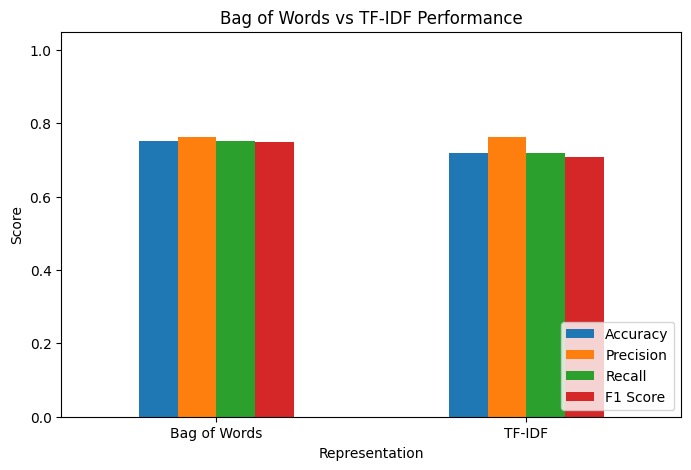

In [176]:

import matplotlib.pyplot as plt

results_plot = results.set_index("Representation")

results_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Bag of Words vs TF-IDF Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [159]:
from sklearn.linear_model import LogisticRegression

In [160]:
model_lR=LogisticRegression()
model_lR.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [161]:
y_pred_lR=model_lR.predict(X_test__tfidf)

In [162]:
accuracy=accuracy_score(y_test, y_pred_lR)
print(f'Accuracy: {accuracy}')

Accuracy: 0.7850078830442884
